# GeoBench EverWatch

## Intro

EverWatch [(Garner et al. 2024)](https://zenodo.org/records/11165946) is a dataset for aerial bird detection in high-resolution wildlife monitoring imagery. The dataset focuses on automated detection and monitoring of bird species using aerial drone imagery. It addresses the critical challenge of wildlife conservation through automated aerial monitoring, providing precise bird detection capabilities for ecological research and conservation efforts.

## Dataset Characteristics

- **Modalities**: 
  - High-resolution RGB aerial imagery from drones
- **Spatial Resolution**: Sub-meter resolution (typical 0.1-0.5m/pixel)
- **Temporal Resolution**: Single acquisitions per location
- **Spectral Bands**: 
  - RGB: 3 channels (Red, Green, Blue)
- **Image Dimensions**: Variable sizes (typically 1000-4000 pixels)
- **Labels**: Bird object detection bounding boxes
  - Annotations for seven bird species
- **Geographic Distribution**: Locations across the Everglades, Florida, USA

## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Image Processing**:
   - Resize variable-size drone imagery to consistent patches of size 512x512

2. **Split Generation**:
   - Use original train/test split from dataset, create a validation set from splitting on different colony locations (which is metadata info available for some but not all images)


## References

1. Garner, Lindsey, Ben Weinstein, Michael Rickershauser, Melissa Baldino, Holly Coates, Mary Commins, Tracey Faber, et al. “Everwatch Benchmark: Training and Evaluation Data for Detection and Species Classification of Everglades Wading Birds from Airborne Imagery”. Zenodo, May 13, 2024. https://doi.org/10.5281/zenodo.11165946.

In [1]:
import os
from pathlib import Path

import torch
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
)

from geobench_v2.datamodules import GeoBenchEverWatchDataModule
from geobench_v2.datasets import GeoBenchEverWatch
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/everwatch")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "everwatch_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "everwatch_stats_clip_rescale.json")

In [ ]:
band_order = GeoBenchEverWatch.band_default_order

datamodule = GeoBenchEverWatchDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


## Dataset Statistics

Computed over the training dataset.

### Image Statistics

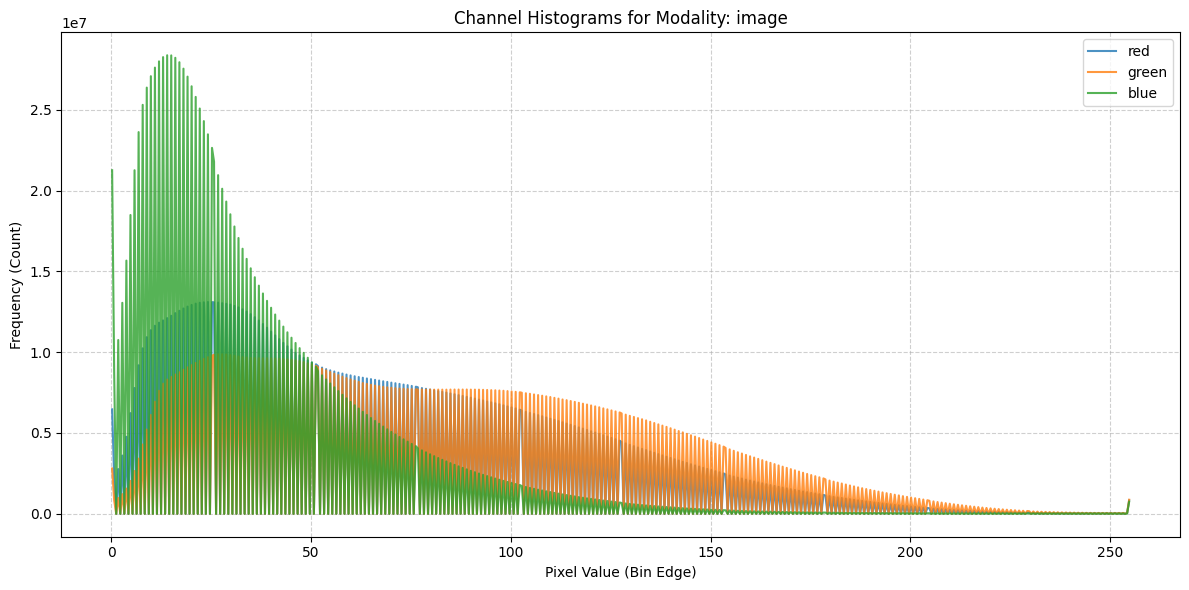

In [4]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

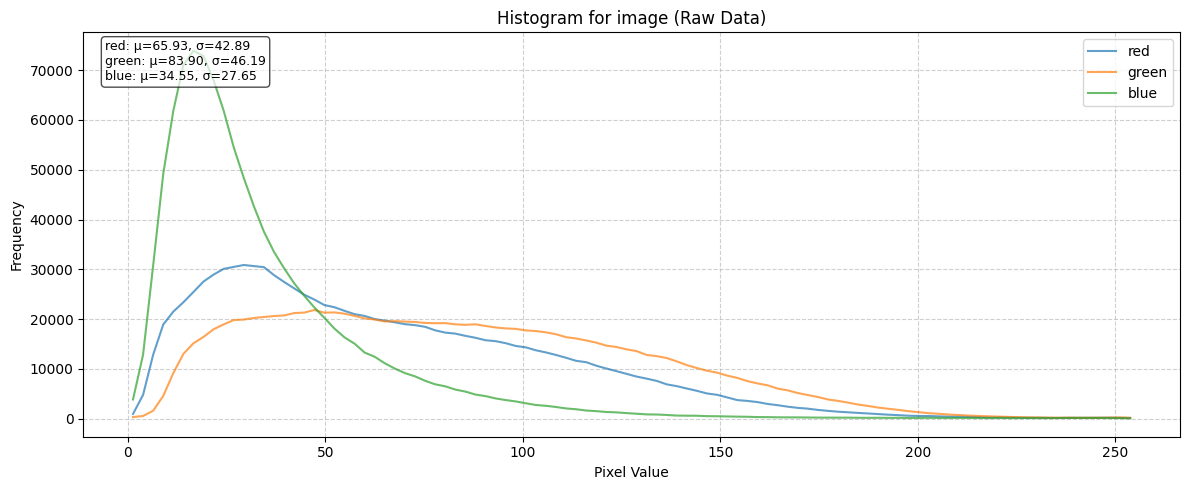

In [6]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

In [7]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

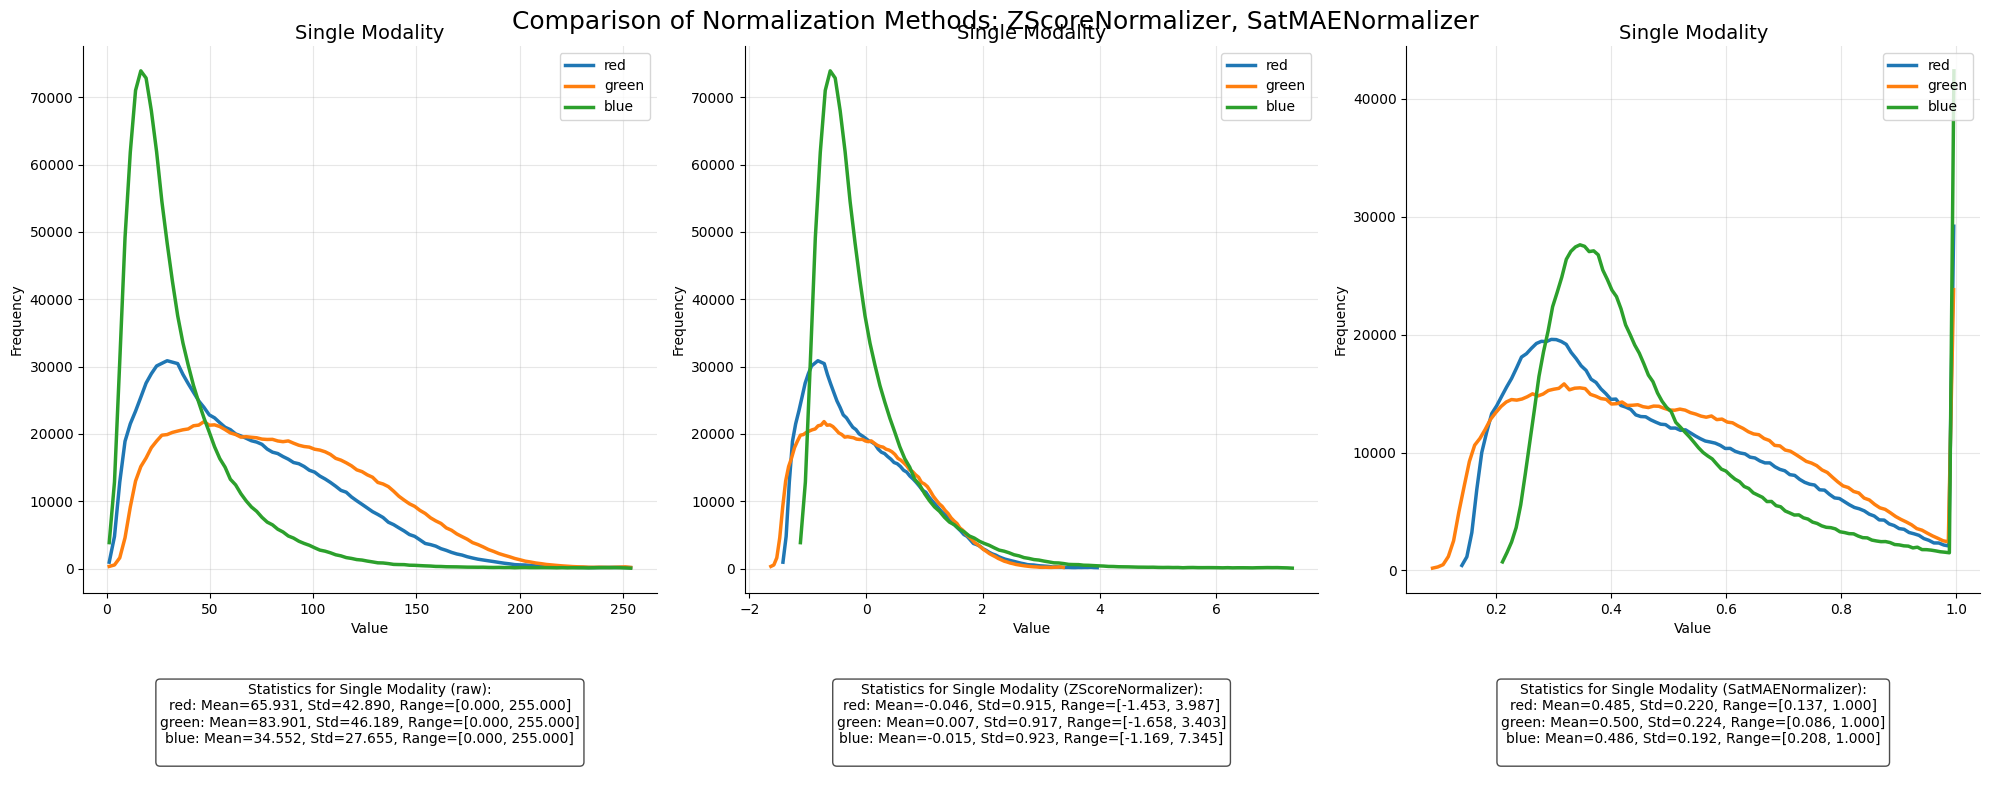

In [8]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

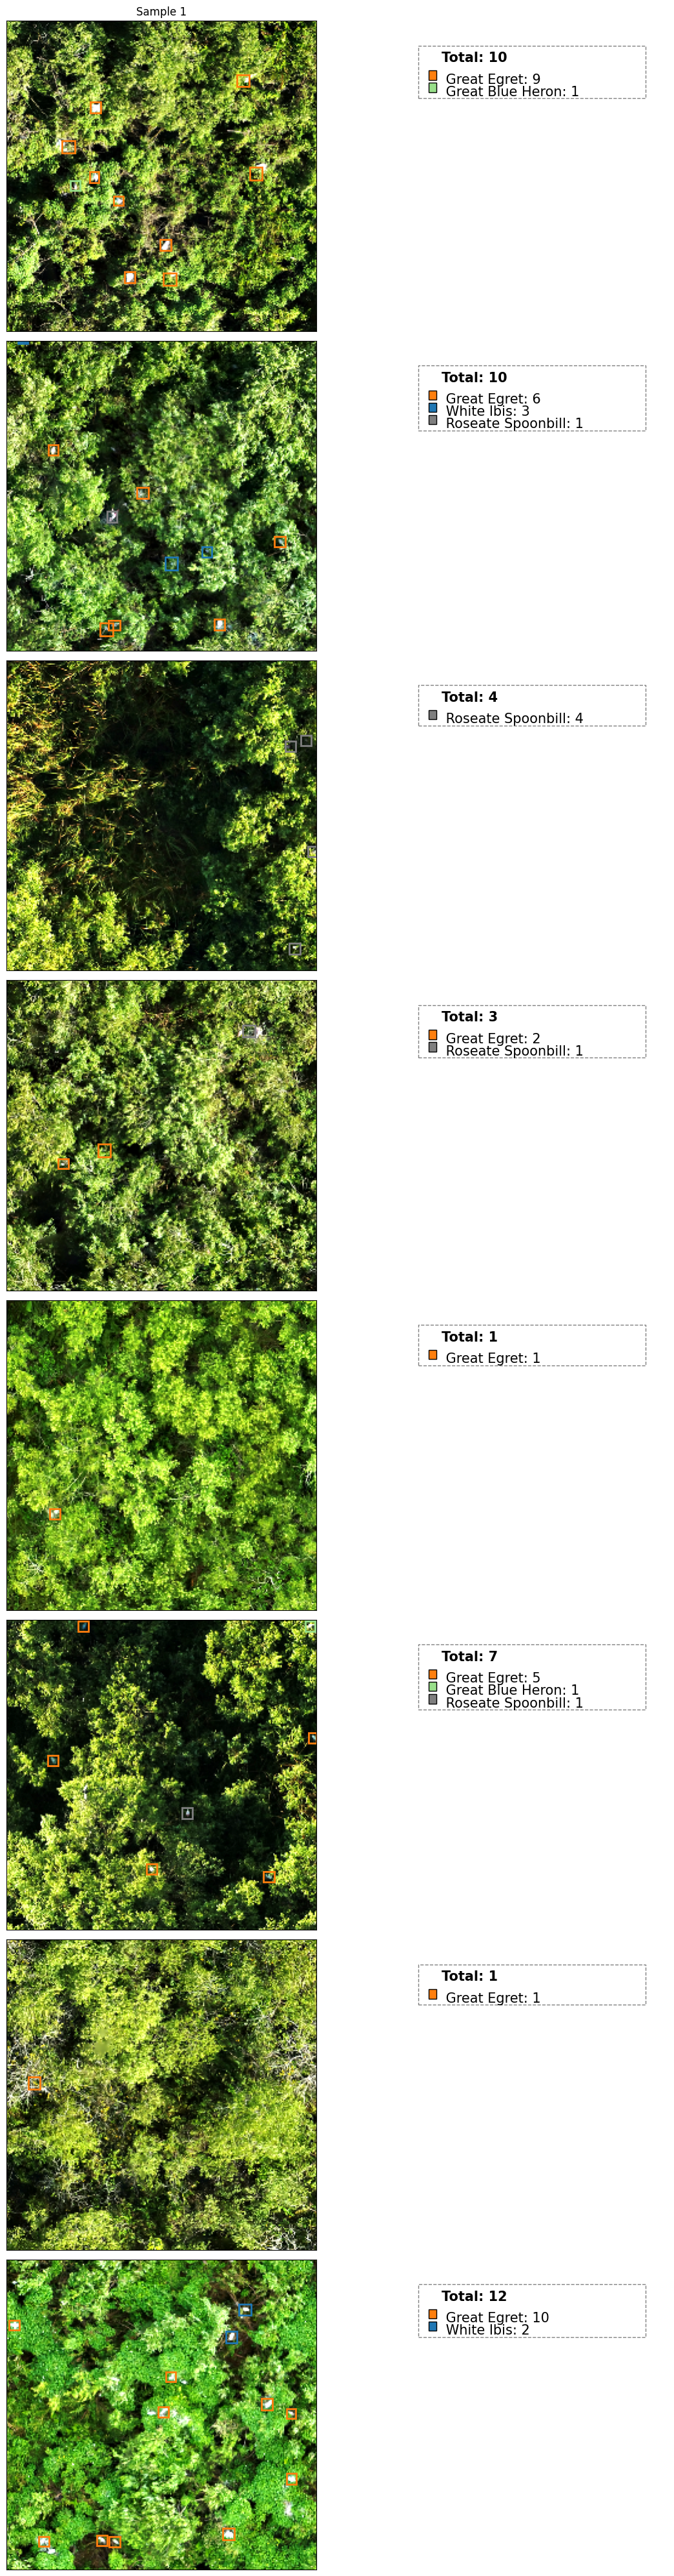

In [9]:
fig, batch = datamodule.visualize_batch()